# Q1: K-fold Cross-Validation

Continuation of Assignment 1 `Real_World_Classification.ipynb`.  
Using updated `linear_model.py` from the course GitHub.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, cross_val_score, KFold

from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

seed = 40
np.random.seed(seed)

## Data Preprocessing (reproduced from Assignment 1, Q3)

In [2]:
# Load data
df = pd.read_csv('data/NYCU_Iris.csv')

# Label encoding
df['Species'] = df['Species'].astype(str).str.strip()
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

# Convert to numeric
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df[feature_cols] = imputer.fit_transform(df[feature_cols])

# Train-test split (same as A1)
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

# MinMaxScaler: fit on training data only
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Label distribution - Train: {np.bincount(y_train)}, Test: {np.bincount(y_test)}")

X_train: (350, 70), X_test: (150, 70)
Label distribution - Train: [166 184], Test: [74 76]


## 1(a) 5-Fold Cross-Validation: 4x4 hyperparameter grid

In [3]:
# Hyperparameter grid
learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

# KFold as specified by assignment
kf = KFold(n_splits=5, shuffle=True, random_state=40)

# Run cross-validation for all 16 combinations
results = np.zeros((len(learning_rates), len(reg_lambdas)))

for i, lr in enumerate(learning_rates):
    for j, reg_lambda in enumerate(reg_lambdas):
        model = LinearModel(
            dim=X_train.shape[1],
            is_reg=False,
            loss_fn=logloss,
            act_fn=sigmoid,
            grad_fn=logloss_sigmoid_grad,
            lr=lr,
            reg_type='l2',
            reg_lambda=reg_lambda,
            n_iteration=10000,
            val_ratio=0.2,
            random_state=seed,
            verbose=False,
            plot_curve=False
        )
        scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
        results[i, j] = scores.mean()
        print(f"lr={lr}, lambda={reg_lambda}: mean_acc={scores.mean():.4f} (std={scores.std():.4f})")

# Display as 4x4 table
results_df = pd.DataFrame(
    results,
    index=[f'lr={lr}' for lr in learning_rates],
    columns=[f'lambda={lam}' for lam in reg_lambdas]
)
print("\n=== 4x4 Cross-Validation Accuracy Table ===")
results_df

lr=0.005, lambda=1.0: mean_acc=0.7200 (std=0.0420)


lr=0.005, lambda=2.0: mean_acc=0.7257 (std=0.0514)


lr=0.005, lambda=4.0: mean_acc=0.7314 (std=0.0377)


lr=0.005, lambda=8.0: mean_acc=0.7257 (std=0.0291)


lr=0.01, lambda=1.0: mean_acc=0.7257 (std=0.0609)


...

lr=0.5, lambda=1.0: mean_acc=0.7171 (std=0.0388)


lr=0.5, lambda=2.0: mean_acc=0.6886 (std=0.0481)


lr=0.5, lambda=4.0: mean_acc=0.5229 (std=0.0114)


lr=0.5, lambda=8.0: mean_acc=0.4657 (std=0.0280)

=== 4x4 Cross-Validation Accuracy Table ===


,lambda=1.0,lambda=2.0,lambda=4.0,lambda=8.0
lr=0.005,0.720000,0.725714,0.731429,0.725714
lr=0.01,0.725714,0.728571,0.728571,0.722857
lr=0.1,0.717143,0.728571,0.725714,0.722857
lr=0.5,0.717143,0.688571,0.522857,0.465714


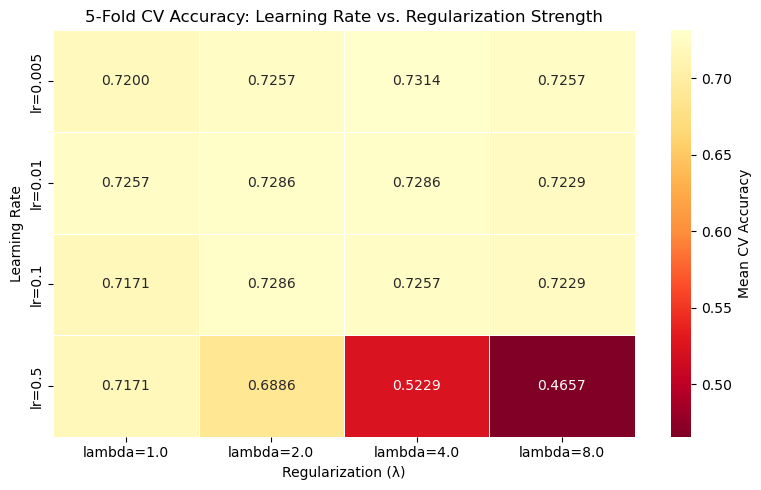

In [4]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(results_df, annot=True, fmt='.4f', cmap='YlOrRd_r', linewidths=0.5,
            cbar_kws={'label': 'Mean CV Accuracy'}, ax=ax)
ax.set_title('5-Fold CV Accuracy: Learning Rate vs. Regularization Strength')
ax.set_ylabel('Learning Rate')
ax.set_xlabel('Regularization (λ)')
plt.tight_layout()
plt.savefig('report/figures/q1_cv_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 1(b) Top 2 hyperparameter settings → Test evaluation

=== Top 2 Hyperparameter Settings (by CV accuracy) ===
  #1: lr=0.005, lambda=4.0, CV accuracy=0.7314
  #2: lr=0.1, lambda=2.0, CV accuracy=0.7286

Top #1: lr=0.005, reg_lambda=4.0


Top #1: lr=0.005, lambda=4.0
Accuracy  : 0.7600
Precision : 0.7273
Recall    : 0.8421
F1-score  : 0.7805


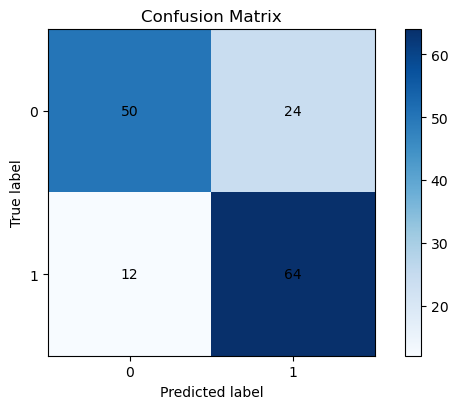


Top #2: lr=0.1, reg_lambda=2.0


Top #2: lr=0.1, lambda=2.0
Accuracy  : 0.7467
Precision : 0.7209
Recall    : 0.8158
F1-score  : 0.7654


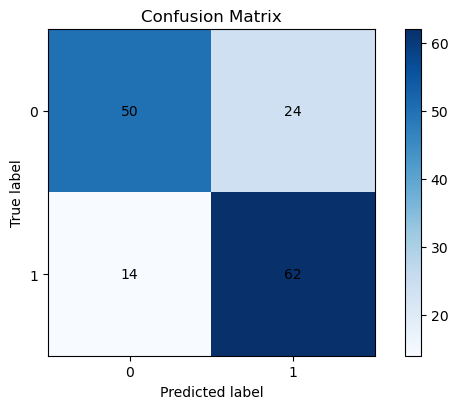

In [5]:
# Find top 2 hyperparameter combinations
flat_results = []
for i, lr in enumerate(learning_rates):
    for j, reg_lambda in enumerate(reg_lambdas):
        flat_results.append((results[i, j], lr, reg_lambda))
flat_results.sort(reverse=True)

print("=== Top 2 Hyperparameter Settings (by CV accuracy) ===")
for rank, (acc, lr, reg_lambda) in enumerate(flat_results[:2], 1):
    print(f"  #{rank}: lr={lr}, lambda={reg_lambda}, CV accuracy={acc:.4f}")

# Train on full training set and evaluate on test set for top 2
for rank, (acc, lr, reg_lambda) in enumerate(flat_results[:2], 1):
    print(f"\n{'='*60}")
    print(f"Top #{rank}: lr={lr}, reg_lambda={reg_lambda}")
    print(f"{'='*60}")
    
    model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=logloss,
        act_fn=sigmoid,
        grad_fn=logloss_sigmoid_grad,
        lr=lr,
        reg_type='l2',
        reg_lambda=reg_lambda,
        n_iteration=10000,
        val_ratio=0.2,
        random_state=seed,
        verbose=False,
        plot_curve=False
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred, title=f'Top #{rank}: lr={lr}, lambda={reg_lambda}')

## 1(c) Observations

**Cross-Validation Results (1a):**
- The best CV accuracy (73.1%) is achieved with lr=0.005, lambda=4.0, while most small learning rates (0.005, 0.01, 0.1) achieve similar performance (~72-73%) regardless of lambda, indicating the model is relatively robust to regularization strength at moderate learning rates.
- A large learning rate (lr=0.5) combined with strong regularization (lambda=4.0 or 8.0) causes significant performance degradation (52.3% and 46.6%), suggesting that when the gradient steps are too large and regularization pulls weights aggressively toward zero, the model underfits badly.
- Smaller learning rates (0.005, 0.01) show more stable performance across different lambda values (std ~3-5%), while lr=0.5 shows the widest variance, confirming that slower convergence with gradient descent leads to more consistent training.

**Test Evaluation (1b):**
- The top-1 setting (lr=0.005, lambda=4.0) achieves 76.0% test accuracy with F1=78.1%, outperforming the top-2 setting (lr=0.1, lambda=2.0) which achieves 74.7% accuracy and F1=76.5%.
- Both top settings generalize reasonably well from CV (~73%) to test (~75-76%), indicating that 5-fold CV provides a reliable estimate of generalization performance.
- The top-1 model shows higher recall (84.2%) than precision (72.7%), meaning it is better at identifying positive samples but produces more false positives.